# Лабораторная работа №4
## Оптимизация архитектуры нейронной сети с помощью эволюционных алгоритмов

## 1. Импорт библиотек

In [1]:
import numpy as np
import random
import copy
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

I0000 00:00:1780540448.174407   97689 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780540448.215779   97689 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0


I0000 00:00:1780540449.177442   97689 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_autotune_level=0'

import tensorflow as tf

# Отключаем JIT-компиляцию XLA
tf.config.optimizer.set_jit(False)

# Постепенное выделение памяти
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU: {gpus[0].name}")

GPU: /physical_device:GPU:0


## 2. Загрузка и подготовка данных

In [3]:
data = fetch_covtype()
X, y = data.data, data.target - 1

print(f'Полный датасет: {X.shape[0]} образцов, {X.shape[1]} признаков, {len(np.unique(y))} классов')

SAMPLE_SIZE = 30_000
idx = []
for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    n = int(SAMPLE_SIZE * len(cls_idx) / len(y))
    idx.extend(np.random.choice(cls_idx, size=max(n, 100), replace=False))
idx = np.array(idx)
np.random.shuffle(idx)
X, y = X[idx], y[idx]

print(f'Подвыборка:     {X.shape[0]} образцов')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

N_FEATURES = X_train.shape[1]
N_CLASSES  = len(np.unique(y))

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')
print(f'Признаков: {N_FEATURES}, Классов: {N_CLASSES}')

Полный датасет: 581012 образцов, 54 признаков, 7 классов
Подвыборка:     29997 образцов
Train: 20997, Val: 4500, Test: 4500
Признаков: 54, Классов: 7


## 3. Генотип особи и вспомогательные функции

In [4]:
ACTIVATION_OPTIONS = ['relu', 'tanh', 'elu', 'selu']
L2_OPTIONS         = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
NEURON_CHOICES     = list(range(16, 513, 16))
MIN_LAYERS, MAX_LAYERS = 1, 5


def random_individual():
    n = random.randint(MIN_LAYERS, MAX_LAYERS)
    return {
        'n_layers':   n,
        'neurons':    [random.choice(NEURON_CHOICES) for _ in range(n)],
        'activation': random.choice(ACTIVATION_OPTIONS),
        'l2_reg':     random.choice(L2_OPTIONS),
    }


def count_params(ind):
    total = 0
    prev = N_FEATURES
    for n in ind['neurons']:
        total += prev * n + n
        prev = n
    total += prev * N_CLASSES + N_CLASSES
    return total


def build_model(ind):
    reg = regularizers.l2(ind['l2_reg'])
    model = keras.Sequential()
    model.add(layers.Input(shape=(N_FEATURES,)))
    for n in ind['neurons']:
        model.add(layers.Dense(n, activation=ind['activation'],
                               kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))
    model.add(layers.Dense(N_CLASSES, activation='softmax'))
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print('Пример случайной особи:')
ex = random_individual()
print(ex)
print(f'  → ~{count_params(ex):,} параметров')

Пример случайной особи:
{'n_layers': 1, 'neurons': [32], 'activation': 'elu', 'l2_reg': 5e-05}
  → ~1,991 параметров


## 4. Фитнес-функция

In [5]:
EVAL_EPOCHS    = 20
EVAL_BATCH     = 256
ALPHA_LAYERS   = 0.02
BETA_PARAMS    = 0.01
MAX_PARAMS_LOG = np.log10(count_params({
    'n_layers': MAX_LAYERS,
    'neurons': [512] * MAX_LAYERS,
    'activation': 'relu',
    'l2_reg': 1e-5
}))

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=3,
    restore_best_weights=True, verbose=0
)


def evaluate_individual(ind):
    model = build_model(ind)
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EVAL_EPOCHS,
        batch_size=EVAL_BATCH,
        callbacks=[early_stop],
        verbose=0
    )
    val_acc = model.evaluate(X_val, y_val, verbose=0)[1]
    n_params = model.count_params()

    penalty_layers  = ALPHA_LAYERS * (ind['n_layers'] / MAX_LAYERS)
    penalty_params  = BETA_PARAMS  * (np.log10(max(n_params, 1)) / MAX_PARAMS_LOG)
    fitness = val_acc - penalty_layers - penalty_params

    keras.backend.clear_session()
    return fitness, val_acc, n_params

print(f'MAX_PARAMS_LOG = {MAX_PARAMS_LOG:.3f}')

MAX_PARAMS_LOG = 6.034


## 5. Операторы эволюционного алгоритма

In [6]:
def tournament_selection(population, fitnesses, k=3):
    candidates = random.sample(range(len(population)), k)
    best = max(candidates, key=lambda i: fitnesses[i])
    return copy.deepcopy(population[best])


def crossover(parent1, parent2):
    child = {}

    if random.random() < 0.5:
        child['n_layers'] = parent1['n_layers']
        child['neurons']  = copy.deepcopy(parent1['neurons'])
    else:
        child['n_layers'] = parent2['n_layers']
        child['neurons']  = copy.deepcopy(parent2['neurons'])

    child['activation'] = random.choice(
        [parent1['activation'], parent2['activation']]
    )
    child['l2_reg'] = random.choice(
        [parent1['l2_reg'], parent2['l2_reg']]
    )
    return child


def mutate(ind, mutation_rate=0.3):
    ind = copy.deepcopy(ind)

    if random.random() < mutation_rate:
        layer_idx = random.randint(0, ind['n_layers'] - 1)
        ind['neurons'][layer_idx] = random.choice(NEURON_CHOICES)

    if random.random() < mutation_rate and ind['n_layers'] < MAX_LAYERS:
        pos = random.randint(0, ind['n_layers'])
        ind['neurons'].insert(pos, random.choice(NEURON_CHOICES))
        ind['n_layers'] += 1

    elif random.random() < mutation_rate and ind['n_layers'] > MIN_LAYERS:
        pos = random.randint(0, ind['n_layers'] - 1)
        ind['neurons'].pop(pos)
        ind['n_layers'] -= 1

    if random.random() < mutation_rate:
        ind['activation'] = random.choice(ACTIVATION_OPTIONS)

    # Мутация коэффициента регуляризации
    if random.random() < mutation_rate:
        ind['l2_reg'] = random.choice(L2_OPTIONS)

    return ind

## 6. Главный цикл эволюционного алгоритма

In [7]:
POP_SIZE       = 12
N_GENERATIONS  = 25
ELITE_SIZE     = 2
MUTATION_RATE  = 0.30
CROSSOVER_PROB = 0.80

population = [random_individual() for _ in range(POP_SIZE)]

history_best_fitness = []
history_mean_fitness = []
history_best_acc     = []
history_mean_acc     = []

best_individual  = None
best_fitness_val = -np.inf

print(f'Начало эволюции: {POP_SIZE} особей × {N_GENERATIONS} поколений')
print('=' * 65)

for gen in range(1, N_GENERATIONS + 1):

    results  = [evaluate_individual(ind) for ind in population]
    fitnesses  = [r[0] for r in results]
    accuracies = [r[1] for r in results]

    gen_best_idx = int(np.argmax(fitnesses))
    gen_best_fit = fitnesses[gen_best_idx]
    gen_mean_fit = float(np.mean(fitnesses))
    gen_best_acc = accuracies[gen_best_idx]
    gen_mean_acc = float(np.mean(accuracies))

    history_best_fitness.append(gen_best_fit)
    history_mean_fitness.append(gen_mean_fit)
    history_best_acc.append(gen_best_acc)
    history_mean_acc.append(gen_mean_acc)

    if gen_best_fit > best_fitness_val:
        best_fitness_val = gen_best_fit
        best_individual  = copy.deepcopy(population[gen_best_idx])
        marker = '★'
    else:
        marker = ' '

    arch_str = 'x'.join(str(n) for n in population[gen_best_idx]['neurons'])
    print(f'{marker} Поколение {gen:2d}/{N_GENERATIONS} | '
          f'Лучший fitness={gen_best_fit:.4f} acc={gen_best_acc:.4f} | '
          f'Средний acc={gen_mean_acc:.4f} | Арх: [{arch_str}]')

    elite_indices = sorted(range(POP_SIZE),
                           key=lambda i: fitnesses[i], reverse=True)[:ELITE_SIZE]
    new_population = [copy.deepcopy(population[i]) for i in elite_indices]

    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        if random.random() < CROSSOVER_PROB:
            p2  = tournament_selection(population, fitnesses)
            child = crossover(p1, p2)
        else:
            child = copy.deepcopy(p1)
        child = mutate(child, MUTATION_RATE)
        new_population.append(child)

    population = new_population

print('=' * 65)
print(f'\nЛучшая найденная архитектура:')
print(f'  Слоёв:      {best_individual["n_layers"]}')
print(f'  Нейроны:    {best_individual["neurons"]}')
print(f'  Активация:  {best_individual["activation"]}')
print(f'  L2 reg:     {best_individual["l2_reg"]}')
print(f'  Fitness:    {best_fitness_val:.4f}')

Начало эволюции: 12 особей × 25 поколений


I0000 00:00:1780540449.905061   97689 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4353 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1780540451.531321   97949 service.cc:153] XLA service 0x7a47ec034cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780540451.531335   97949 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780540451.557098   97949 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780540451.731493   97949 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780540451.784956   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2404__.30
I0000 00:00:1780540452.013253   97949 dot_search_s

★ Поколение  1/25 | Лучший fitness=0.7629 acc=0.7782 | Средний acc=0.6898 | Арх: [144x112]


I0000 00:00:1780540605.021236   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81454__.30
I0000 00:00:1780540606.986361   97947 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_81454__.30
I0000 00:00:1780540611.621965   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_85308__.21
I0000 00:00:1780540612.862220   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_85308__.21
I0000 00:00:1780540618.480607   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_92564__.57
I0000 00:00:1780540623.488688   97951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_92564__.57
I0000 00:00:1780540632.150870   97951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96692__.21
I0000 00:00:1780540633.425523   97948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_966

  Поколение  2/25 | Лучший fitness=0.6862 acc=0.6969 | Средний acc=0.6943 | Арх: [176]


...

  Поколение 23/25 | Лучший fitness=0.7036 acc=0.7240 | Средний acc=0.6912 | Арх: [480x144x112]


I0000 00:00:1780542950.771394   97947 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1405990__.39
I0000 00:00:1780542953.816635   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1405990__.39
I0000 00:00:1780542961.930870   97947 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1410814__.30
I0000 00:00:1780542964.078433   97948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1410814__.30
I0000 00:00:1780542971.021052   97948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1415536__.30
I0000 00:00:1780542973.017533   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1415536__.30
I0000 00:00:1780542980.104396   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1421134__.39
I0000 00:00:1780542980.186176   97949 dot_search_space.cc:240] All configs were filtered out because non

  Поколение 24/25 | Лучший fitness=0.7054 acc=0.7258 | Средний acc=0.6965 | Арх: [304x208x144]


I0000 00:00:1780543072.615312   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1468546__.39
I0000 00:00:1780543075.774180   97951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1468546__.39
I0000 00:00:1780543085.805699   97948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1474238__.39
I0000 00:00:1780543092.159578   97951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1474238__.39
I0000 00:00:1780543108.070618   97947 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1478186__.21
I0000 00:00:1780543109.605756   97948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1478186__.21
I0000 00:00:1780543115.516738   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1481946__.21
I0000 00:00:1780543116.966439   97947 dot_merger.cc:481] Merging Dots in computation: a_inference_one_st

  Поколение 25/25 | Лучший fitness=0.7042 acc=0.7202 | Средний acc=0.7053 | Арх: [336x144]

Лучшая найденная архитектура:
  Слоёв:      2
  Нейроны:    [144, 112]
  Активация:  relu
  L2 reg:     0.001
  Fitness:    0.7629


## 7. Визуализация: динамика эволюции

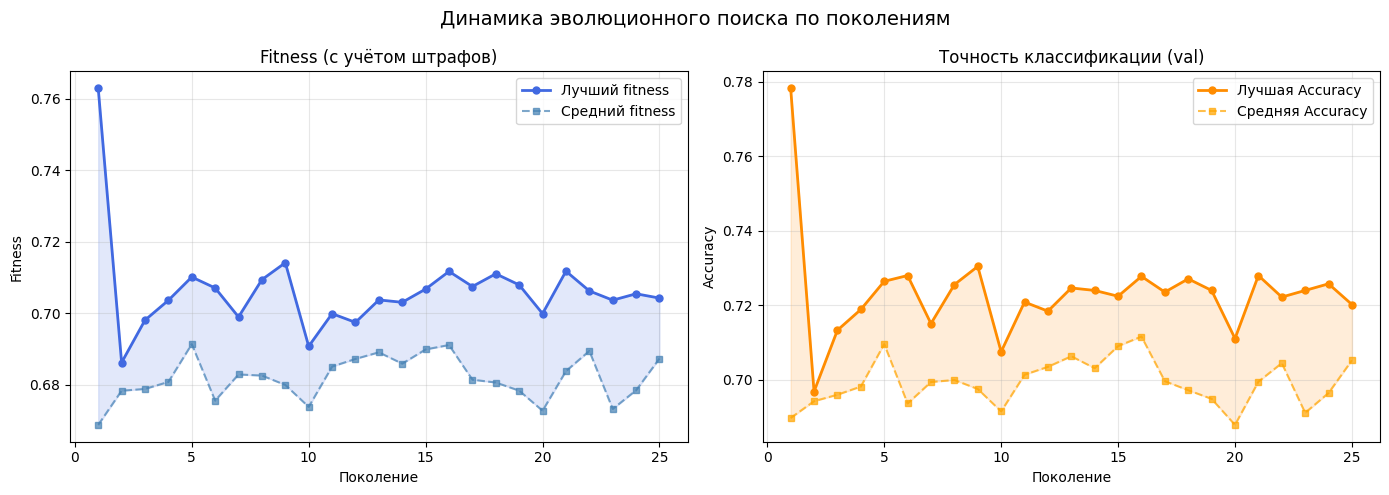

In [8]:
generations = list(range(1, N_GENERATIONS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Динамика эволюционного поиска по поколениям', fontsize=14)

ax = axes[0]
ax.plot(generations, history_best_fitness, 'o-', color='royalblue',
        linewidth=2, markersize=5, label='Лучший fitness')
ax.plot(generations, history_mean_fitness, 's--', color='steelblue',
        linewidth=1.5, markersize=4, alpha=0.7, label='Средний fitness')
ax.fill_between(generations, history_mean_fitness, history_best_fitness,
                alpha=0.15, color='royalblue')
ax.set_xlabel('Поколение')
ax.set_ylabel('Fitness')
ax.set_title('Fitness (с учётом штрафов)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(generations, history_best_acc, 'o-', color='darkorange',
        linewidth=2, markersize=5, label='Лучшая Accuracy')
ax.plot(generations, history_mean_acc, 's--', color='orange',
        linewidth=1.5, markersize=4, alpha=0.7, label='Средняя Accuracy')
ax.fill_between(generations, history_mean_acc, history_best_acc,
                alpha=0.15, color='darkorange')
ax.set_xlabel('Поколение')
ax.set_ylabel('Accuracy')
ax.set_title('Точность классификации (val)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Обучение лучшей найденной модели

In [9]:
print(f'Архитектура: {best_individual}')

best_model = build_model(best_individual)
best_model.summary()

final_early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)

history_final = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[final_early_stop],
    verbose=1
)

y_pred_best = best_model.predict(X_test, verbose=0).argmax(axis=1)
acc_best  = accuracy_score(y_test, y_pred_best)
f1_best   = f1_score(y_test, y_pred_best, average='weighted')

print(f'\n[Лучшая эволюционная модель]')
print(f'  Test Accuracy : {acc_best:.4f}')
print(f'  Test F1-score : {f1_best:.4f}')
print(f'  Параметров    : {best_model.count_params():,}')

Архитектура: {'n_layers': 2, 'neurons': [144, 112], 'activation': 'relu', 'l2_reg': 0.001}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 144)            │         7,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 144)            │           576 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 112)            │        16,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112)            │           448 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           791 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,975 (101.46 KB)

 Trainable params: 25,463 (99.46 KB)

...

Epoch 1/60


I0000 00:00:1780543335.719276   97951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1530210__.30


47/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3587 - loss: 2.2017 

I0000 00:00:1780543337.633721   97949 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1530210__.30


83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5519 - loss: 1.5952 - val_accuracy: 0.7082 - val_loss: 1.2094
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6800 - loss: 1.1030 - val_accuracy: 0.7262 - val_loss: 0.9523
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6965 - loss: 0.9824 - val_accuracy: 0.7329 - val_loss: 0.8684
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7096 - loss: 0.9082 - val_accuracy: 0.7387 - val_loss: 0.8299
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7153 - loss: 0.8645 - val_accuracy: 0.7420 - val_loss: 0.8006
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7207 - loss: 0.8299 - val_accuracy: 0.7491 - val_loss: 0.7815
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7248 - loss: 0.8027 - val_accuracy: 0.7502 - val_loss: 0.7579
Epoch 8/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7292 - loss: 0.7793 - val_accuracy: 0.7480 - val_loss: 0.7472
Ep

## 9. Обучение базовой модели (ручная архитектура)

In [10]:
baseline_individual = {
    'n_layers':   2,
    'neurons':    [128, 64],
    'activation': 'relu',
    'l2_reg':     1e-4,
}

baseline_model = build_model(baseline_individual)
baseline_model.summary()

baseline_early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=[baseline_early_stop],
    verbose=1
)

y_pred_base = baseline_model.predict(X_test, verbose=0).argmax(axis=1)
acc_base  = accuracy_score(y_test, y_pred_base)
f1_base   = f1_score(y_test, y_pred_base, average='weighted')

print(f'\n[Базовая модель (ручная)]')
print(f'  Test Accuracy : {acc_base:.4f}')
print(f'  Test F1-score : {f1_base:.4f}')
print(f'  Параметров    : {baseline_model.count_params():,}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,519 (64.53 KB)

 Trainable params: 16,135 (63.03 KB)

 Non-trainable params: 384 (1.50 KB)

...

45/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3267 - loss: 2.0659 

I0000 00:00:1780543348.524640   97951 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1546751__.30


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4026 - loss: 1.8556

I0000 00:00:1780543350.428636   97947 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.5283 - loss: 1.5028 - val_accuracy: 0.6920 - val_loss: 1.1568
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6684 - loss: 0.9994 - val_accuracy: 0.7256 - val_loss: 0.8574
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6880 - loss: 0.8757 - val_accuracy: 0.7309 - val_loss: 0.7618
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7010 - loss: 0.7988 - val_accuracy: 0.7344 - val_loss: 0.7128
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7067 - loss: 0.7551 - val_accuracy: 0.7382 - val_loss: 0.6880
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7111 - loss: 0.7277 - val_accuracy: 0.7398 - val_loss: 0.6682
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7194 - loss: 0.7060 - val_accuracy: 0.7453 - val_loss: 0.6568
Epoch 8/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7243 - loss: 0.6861 - val_accuracy: 0.7460 - val_loss: 0.6460
Ep

## 10. Визуализация: кривые обучения

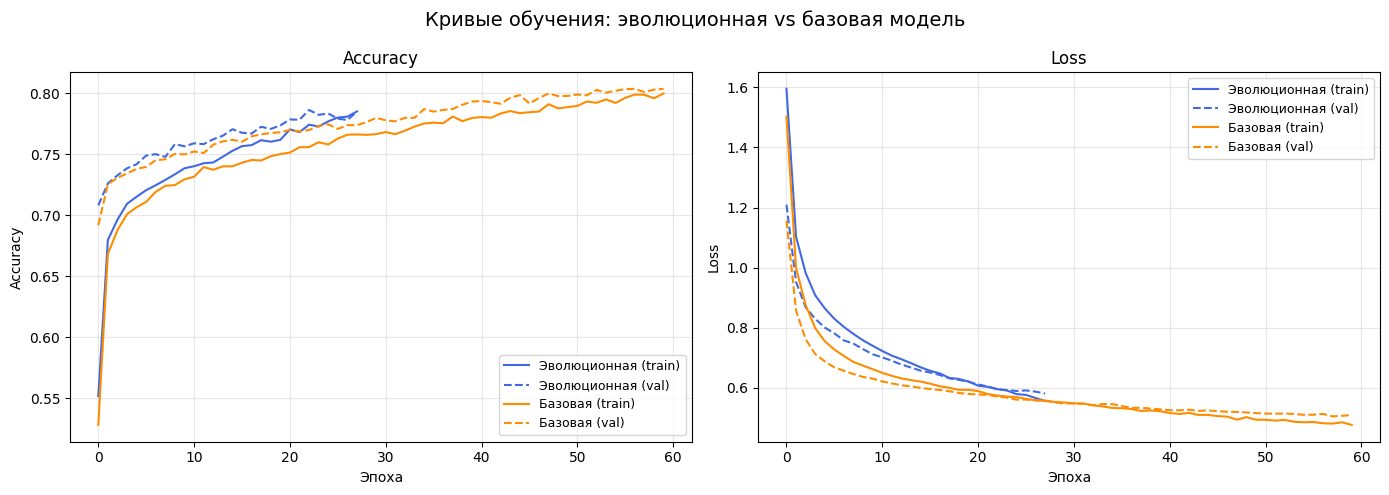

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Кривые обучения: эволюционная vs базовая модель', fontsize=14)

for ax, metric, title in zip(
    axes,
    ['accuracy', 'loss'],
    ['Accuracy', 'Loss']
):
    ax.plot(history_final.history[metric],
            color='royalblue', label=f'Эволюционная (train)')
    ax.plot(history_final.history[f'val_{metric}'],
            color='royalblue', linestyle='--', label=f'Эволюционная (val)')
    ax.plot(history_baseline.history[metric],
            color='darkorange', label=f'Базовая (train)')
    ax.plot(history_baseline.history[f'val_{metric}'],
            color='darkorange', linestyle='--', label=f'Базовая (val)')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Визуализация структуры лучшей нейронной сети

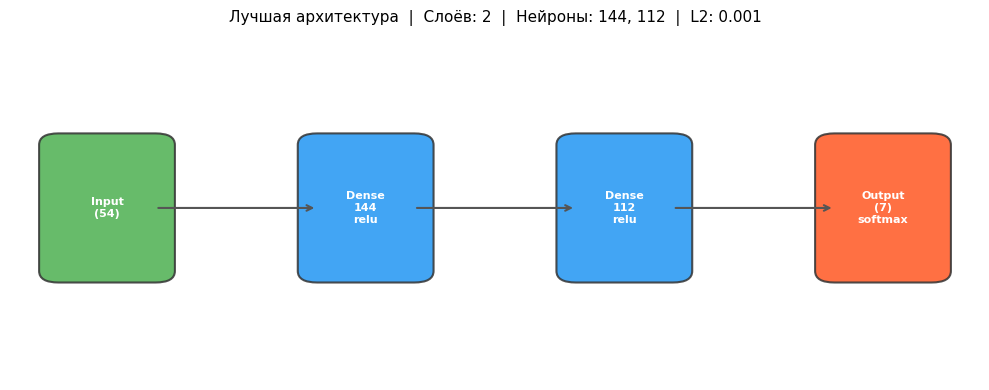

In [12]:
def draw_network(ind, ax):
    layer_sizes = [N_FEATURES] + ind['neurons'] + [N_CLASSES]
    layer_labels = (['Input\n(54)'] +
                    [f'Dense\n{n}\n{ind["activation"]}' for n in ind['neurons']] +
                    ['Output\n(7)\nsoftmax'])
    colors = (['#4CAF50'] +
              ['#2196F3'] * ind['n_layers'] +
              ['#FF5722'])

    n_layers = len(layer_sizes)
    x_positions = np.linspace(0.1, 0.9, n_layers)
    y_center = 0.5
    box_w, box_h = 0.10, 0.22

    for i, (x, label, color) in enumerate(zip(x_positions, layer_labels, colors)):
        rect = mpatches.FancyBboxPatch(
            (x - box_w / 2, y_center - box_h / 2),
            box_w, box_h,
            boxstyle='round,pad=0.02',
            linewidth=1.5,
            edgecolor='#333', facecolor=color, alpha=0.85
        )
        ax.add_patch(rect)
        ax.text(x, y_center, label, ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

        if i < n_layers - 1:
            x_next = x_positions[i + 1]
            ax.annotate('', xy=(x_next - box_w / 2, y_center),
                        xytext=(x + box_w / 2, y_center),
                        arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

    ax.set_xlim(0, 1)
    ax.set_ylim(0.2, 0.8)
    ax.axis('off')
    ax.set_title(
        f'Лучшая архитектура  |  '
        f'Слоёв: {ind["n_layers"]}  |  '
        f'Нейроны: {", ".join(map(str, ind["neurons"]))}  |  '
        f'L2: {ind["l2_reg"]}',
        fontsize=11, pad=10
    )


fig, ax = plt.subplots(figsize=(max(10, best_individual['n_layers'] * 2 + 4), 4))
draw_network(best_individual, ax)
plt.tight_layout()
plt.show()

## 12. Матрица ошибок

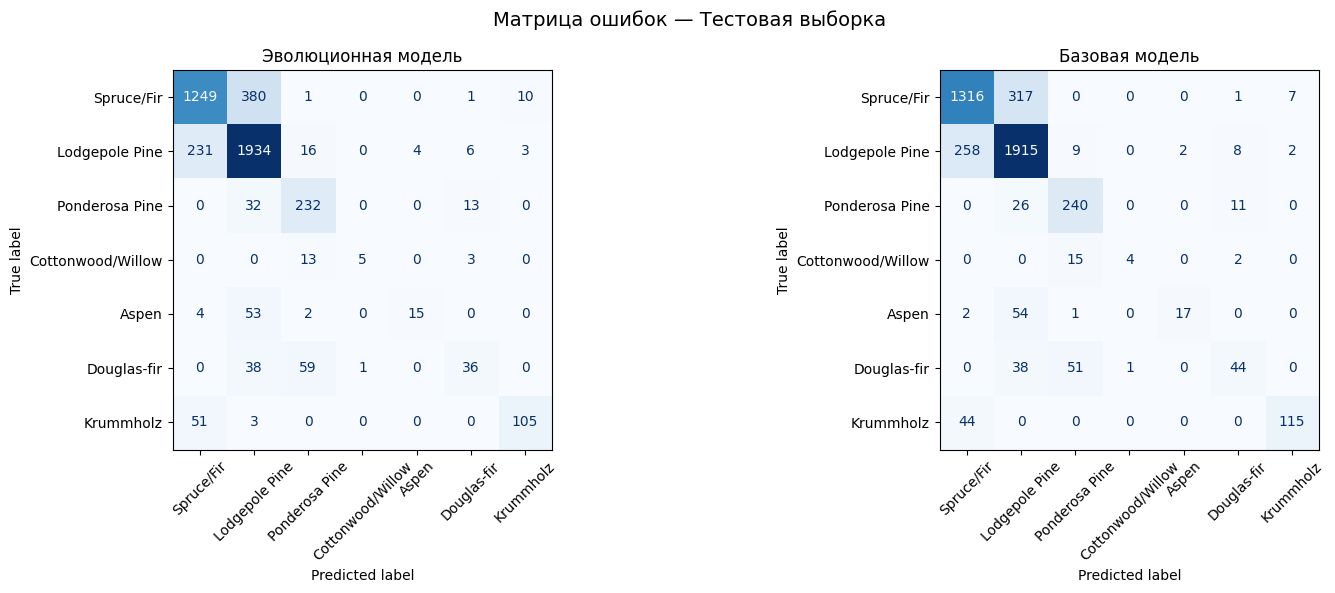

In [13]:
CLASS_NAMES = [
    'Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
    'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Матрица ошибок — Тестовая выборка', fontsize=14)

for ax, y_pred, title in zip(
    axes,
    [y_pred_best, y_pred_base],
    ['Эволюционная модель', 'Базовая модель']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

## 13. Итоговое сравнение результатов

In [14]:
print('=' * 60)
print(f'{"Метрика":<30} {"Эволюционная":>13} {"Базовая":>13}')
print('-' * 60)
print(f'{"Test Accuracy":<30} {acc_best:>13.4f} {acc_base:>13.4f}')
print(f'{"Test F1-score (weighted)":<30} {f1_best:>13.4f} {f1_base:>13.4f}')
print(f'{"Число параметров":<30} {best_model.count_params():>13,} {baseline_model.count_params():>13,}')
print(f'{"Скрытых слоёв":<30} {best_individual["n_layers"]:>13} {baseline_individual["n_layers"]:>13}')
print(f'{"Нейроны (скрытые)":<30} {"+".join(map(str, best_individual["neurons"])):>13} {"+".join(map(str, baseline_individual["neurons"])):>13}')
print(f'{"Функция активации":<30} {best_individual["activation"]:>13} {baseline_individual["activation"]:>13}')
print(f'{"L2 регуляризация":<30} {str(best_individual["l2_reg"]):>13} {str(baseline_individual["l2_reg"]):>13}')
print('=' * 60)
delta_acc = acc_best - acc_base
print(f'\nПрирост Accuracy: {delta_acc:+.4f} ({delta_acc/acc_base*100:+.2f}%)')

Метрика                         Эволюционная       Базовая
------------------------------------------------------------
Test Accuracy                         0.7947        0.8113
Test F1-score (weighted)              0.7863        0.8044
Число параметров                      25,975        16,519
Скрытых слоёв                              2             2
Нейроны (скрытые)                    144+112        128+64
Функция активации                       relu          relu
L2 регуляризация                       0.001        0.0001

Прирост Accuracy: -0.0167 (-2.05%)


## 14. Гистограмма сравнения моделей

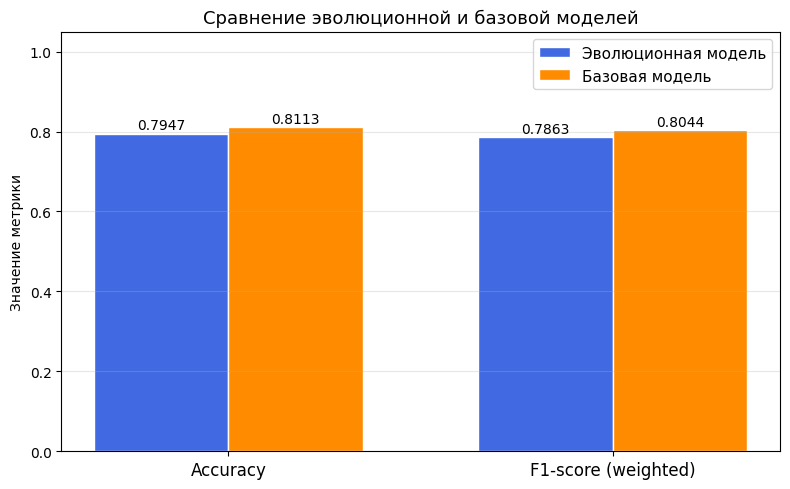

In [15]:
metrics_labels = ['Accuracy', 'F1-score (weighted)']
evo_vals  = [acc_best, f1_best]
base_vals = [acc_base, f1_base]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, evo_vals,  width, label='Эволюционная модель',
               color='royalblue', edgecolor='white')
bars2 = ax.bar(x + width/2, base_vals, width, label='Базовая модель',
               color='darkorange', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение эволюционной и базовой моделей', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()